# Model transfer

One of the defining features of the PCNtoolkit is the ability to transfer models to new data from unseen sites. Transfering a HBR model amounts to estimating batch effect coefficients that follow a distribution that was learned from the original training data. This means that the new coefficients are informed by what is known from previous observations/

We will demonstrate the transfer method here on a small dataset from which we hold out some data. We use the fcon1000 dataset, which is easily loaded from a built-in function in the PCNtoolkit. 



In [1]:
from pcntoolkit import load_fcon1000, HBR, NormativeModel
from pcntoolkit.util.plotter import plot_centiles_advanced
import pcntoolkit

import pandas as pd
import logging
import warnings


# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")
pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(
    action="ignore", category=FutureWarning
)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(
    False
)

In [2]:
# Use default likelihood; Normal, with bspline in mu and sigma, and a random intercept for mu
model = NormativeModel(HBR(progressbar=False), save_dir ="../out/models/transfer_model")

# Load the FCON data
data = load_fcon1000()
# Drop all but the first three response vars
data=data.sel({"response_vars":data.response_vars[:3]})

# Select a few sites at random for transfering
sites_for_transfer = ["Berlin_Margulies", "Oxford"]
# Split by those sites
transfer_data, reference_data = data.batch_effects_split({"site":sites_for_transfer},names=( "transfer", "reference"))
# Split into train and test sets
reference_train, reference_test = reference_data.train_test_split((0.8, 0.2))
transfer_train, transfer_test = transfer_data.train_test_split((0.8, 0.2))

In [3]:
# Fit a model
model.fit_predict(reference_train, reference_test);

c:\Users\kontsi\AppData\Local\anaconda3\envs\ptk-pu25\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


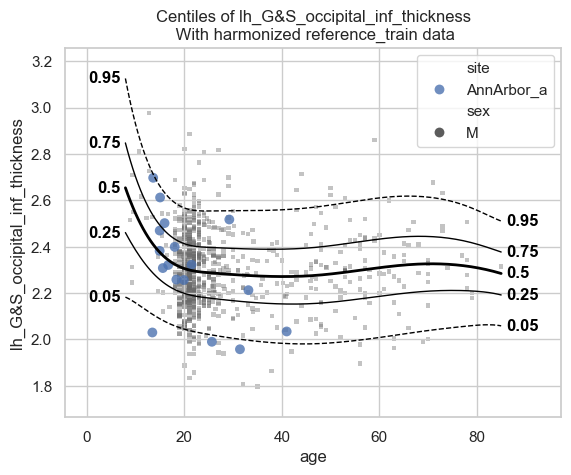

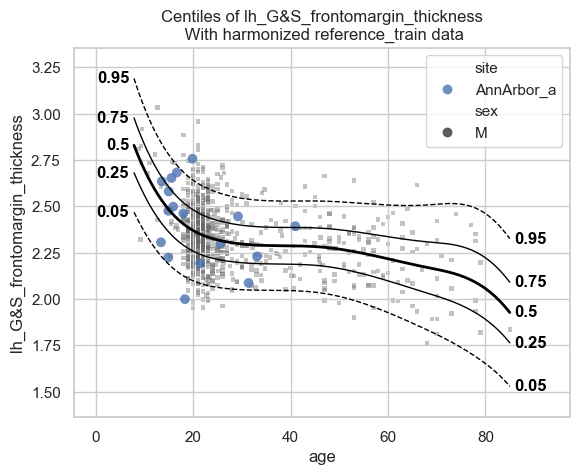

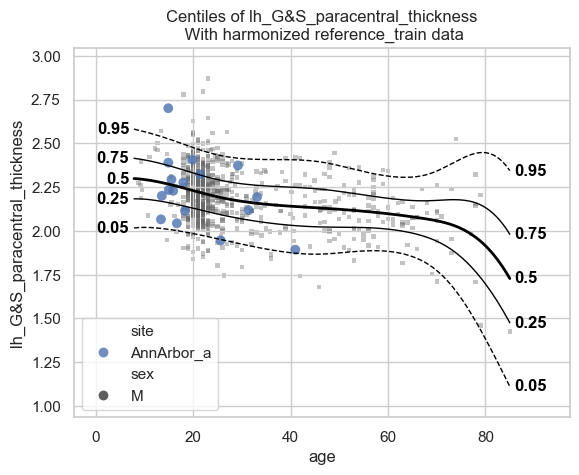

In [4]:
# Show the learned centiles
plot_centiles_advanced(model, scatter_data = reference_train, covariate_range=(10, 80), show_other_data=True)

In [5]:
# Load the model from disk (could also use the model that we just fitted, but this just shows that you can easily load and transfer a model)
fitted_model = NormativeModel.load(model.save_dir)

In [6]:
# Transfer the model and make predictions 
transfered_model = fitted_model.transfer_predict(transfer_train, transfer_test);

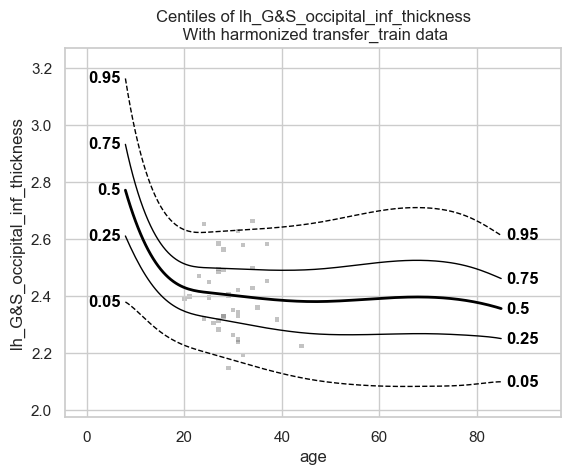

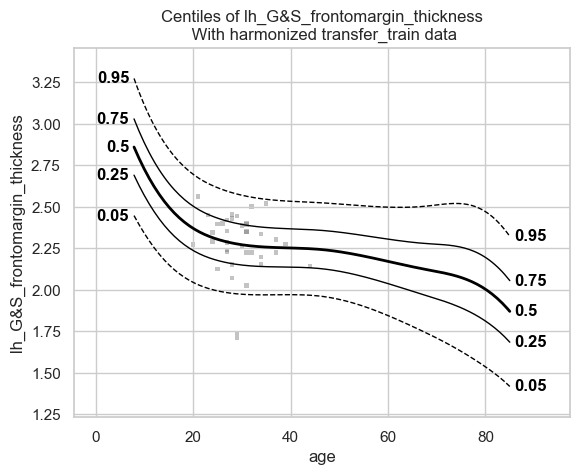

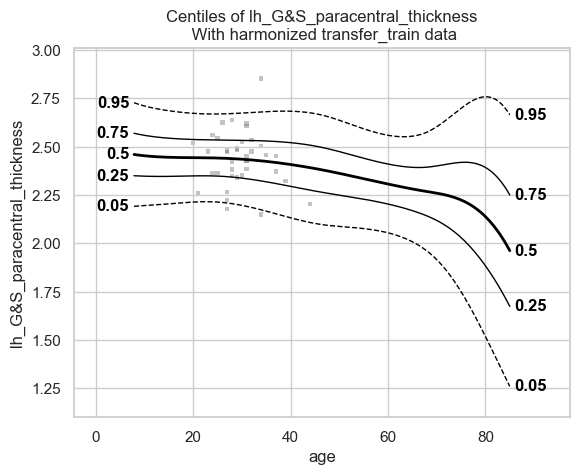

In [7]:
plot_centiles_advanced(transfered_model, scatter_data = transfer_train, covariate_range=(10, 80), show_other_data=True)

The plots show that although there was no available data at the ages above around 45, the transfered model is able to make centile predictions that follow the centiles of the reference model. Simply stated, (almost) all it learned was how much to shift the centiles up or down, given the new data. Nice!
